In [23]:
import chardet
import pandas as pd

# Function to detect file encoding and count lines
def count_lines_in_file(file_path):
    with open(file_path, 'rb') as f:
        raw_data = f.read()
        encoding = chardet.detect(raw_data)['encoding']

    with open(file_path, 'r', encoding=encoding) as f:
        lines = f.readlines()

    return len(lines), encoding

# File paths
training_file = 'Tweets.xlsx'

# Load and analyze the Excel file
def analyze_excel_file(file_path):
    df = pd.read_excel(file_path)
    row_count = df.shape[0]
    columns = df.columns.tolist()
    return row_count, columns

# Analyze the Tweets.xlsx file
row_count, columns = analyze_excel_file(training_file)

# Output the row count and column names
row_count, columns


(4870,
 ['Tweet',
  'Target',
  'Train/Test',
  'Stance',
  'Opinion Toward',
  'Sentiment labels'])

 # Loading Libraries, Coding Detection, Data Preprocessing
This section begins with importing essential libraries such as pandas for data manipulation, re for regular expressions in text preprocessing, and chardet to detect and handle varying file encodings. To ensure the datasets are read without encoding errors, the detect_encoding function is used to determine the correct encoding for both training and test datasets. The datasets, stored in tab-separated files, are then loaded into pandas DataFrames with predefined column names: ['ID', 'Target', 'Tweet', 'Stance', 'Opinion towards', 'Sentiment']. Subsequently, the Tweet column undergoes preprocessing to standardize the text, which involves converting all text to lowercase, removing unwanted special characters while preserving hashtags, slashes, and hyphens, and replacing multiple spaces with a single space. Finally, samples of the original and preprocessed tweets are displayed for both training and test datasets to validate the preprocessing steps

In [24]:
import pandas as pd
import re
import chardet

# Function to detect file encoding using chardet
def detect_encoding(file_path):
    with open(file_path, 'rb') as file:
        raw_data = file.read()
        result = chardet.detect(raw_data)
        return result['encoding']

# File path for Tweets.xlsx file
data_file = 'Tweets.xlsx'

# Load dataset from Excel file
df = pd.read_excel(data_file)

# Filter out rows where Target is "Donald Trump"
df = df[df['Target'] != 'Donald Trump']

# Rename columns for consistency
columns = ['Tweet', 'Target', 'Train/Test', 'Stance', 'Opinion Toward', 'Sentiment labels']
df.columns = columns

# Display first few rows to verify the data
print("Data Sample:")
print(df.head())

# Display dataset information
df.info()


Data Sample:
                                               Tweet  \
0   If abortion is not wrong, then nothing is wro...   
1   Mary, Help of Christians persecuted everywher...   
3  1 Cor 15:58 ...stand firm...Always give yourse...   
4  1 Corinthians 13:13 "So now faith, hope, and l...   
5  1 Holy Mary Mother of God, pray for us sinners...   

                     Target Train/Test   Stance Opinion Toward  \
0  Legalization of Abortion      Train  AGAINST         Target   
1  Legalization of Abortion      Train  AGAINST          Other   
3                   Atheism      Train  AGAINST          Other   
4                   Atheism      Train  AGAINST         Target   
5                   Atheism      Train  AGAINST         Target   

  Sentiment labels  
0              pos  
1              pos  
3              pos  
4              pos  
5              neg  
<class 'pandas.core.frame.DataFrame'>
Index: 4163 entries, 0 to 4869
Data columns (total 6 columns):
 #   Column            Non

In [25]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split

# File path for Tweets.xlsx file
data_file = 'Tweets.xlsx'

# Load dataset from Excel file
df = pd.read_excel(data_file)

# Filter out rows where Target is "Donald Trump"
df = df[df['Target'] != 'Donald Trump']

# Rename columns for consistency
columns = ['Tweet', 'Target', 'Train/Test', 'Stance', 'Opinion Toward', 'Sentiment labels']
df.columns = columns

# Preprocessing steps (lowercase, special characters removal, extra spaces removal)
df["Preprocessed Tweet"] = df["Tweet"].apply(lambda x: x.lower())
df["Preprocessed Tweet"] = df["Preprocessed Tweet"].apply(
    lambda x: re.sub(r"[^\w\s/#-]+", " ", x)  # Allow #, /, and -
)
df["Preprocessed Tweet"] = df["Preprocessed Tweet"].apply(
    lambda x: re.sub(r"\s+", " ", x).strip()
)

# Split the dataset according to given ratios
train_df, temp_df = train_test_split(df, test_size=0.40, random_state=42, stratify=df["Stance"])
dev_df, test_df = train_test_split(temp_df, test_size=0.75, random_state=42, stratify=temp_df["Stance"])

# Verify the splits
print(f"Training set size: {len(train_df)} ({len(train_df) / len(df) * 100:.2f}%)")
print(f"Development set size: {len(dev_df)} ({len(dev_df) / len(df) * 100:.2f}%)")
print(f"Test set size: {len(test_df)} ({len(test_df) / len(df) * 100:.2f}%)")

# Display a sample of the training set
print("\nTraining Data Sample:")
print(train_df[["Tweet", "Preprocessed Tweet", "Stance"]].head())

# Display a sample of the development set
print("\nDevelopment Data Sample:")
print(dev_df[["Tweet", "Preprocessed Tweet", "Stance"]].head())

# Display a sample of the test set
print("\nTest Data Sample:")
print(test_df[["Tweet", "Preprocessed Tweet", "Stance"]].head())


Training set size: 2497 (59.98%)
Development set size: 416 (9.99%)
Test set size: 1250 (30.03%)

Training Data Sample:
                                                  Tweet  \
2436  Girls don't wanna go to the strip with their b...   
648   @HillaryClinton is plain amazing, humble, smar...   
151   @__Porky @P226_Sig @_HankRearden @jrmadmen @ae...   
1370  @tedcruz won't be there. I'm supporting @Hilla...   
3497  My Jesus, I wish to do nothing but Thy most ho...   

                                     Preprocessed Tweet   Stance  
2436  girls don t wanna go to the strip with their b...  AGAINST  
648   hillaryclinton is plain amazing humble smart a...    FAVOR  
151   __porky p226_sig _hankrearden jrmadmen aemdee ...    FAVOR  
1370  tedcruz won t be there i m supporting hillaryc...    FAVOR  
3497  my jesus i wish to do nothing but thy most hol...  AGAINST  

Development Data Sample:
                                                  Tweet  \
4527  We blame cities for the majority 

# Installing the BERT Model and Tokenizer
This section involves loading the pre-trained BERT model and its tokenizer using the transformers library. The tokenizer processes raw text into tokenized representations compatible with the BERT model, while the BERT model itself is used to generate contextual embeddings for the input texts. To optimize performance, the code checks for GPU availability and moves the model to the GPU if accessible.

In [26]:
from transformers import BertTokenizer, BertModel
import torch

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(f"Model and tokenizer {device} loaded.")

Model and tokenizer cpu loaded.


# BERT Embeddings Extraction Function
A function, get_bert_embeddings, is defined to generate embeddings for a list of input texts. This function tokenizes the text, truncates or pads it to a fixed maximum length, and encodes it in a tensor format. The model processes these tensors, and the [CLS] token embedding from the last hidden state is extracted as the representation of the entire text. The embeddings are concatenated and converted into a numpy array for easier handling in subsequent steps.

In [27]:

from tqdm import tqdm

def get_bert_embeddings(texts):

    embeddings = []
    model.eval()
    with torch.no_grad():
        for text in tqdm(texts, desc="BERT emmbeddings created."):

            inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=128)
            inputs = {key: val.to(device) for key, val in inputs.items()}


            outputs = model(**inputs)
            last_hidden_state = outputs.last_hidden_state  # [batch_size, seq_length, hidden_dim]


            cls_embedding = last_hidden_state[:, 0, :]  # [batch_size, hidden_dim]
            embeddings.append(cls_embedding)


    return torch.cat(embeddings, dim=0).cpu().numpy()


BERT Embeddings for Training and Test Data

The code then applies this function to generate BERT embeddings for both the training and test datasets using the preprocessed tweets.

In [30]:
train_texts = train_df["Preprocessed Tweet"].tolist()
test_texts = test_df["Preprocessed Tweet"].tolist()

print("Creating BERT embeddings for training data...")
train_embeddings = get_bert_embeddings(train_texts)

print("Creating BERT embeddings for test data...")
test_embeddings = get_bert_embeddings(test_texts)

dev_texts = dev_df["Preprocessed Tweet"].tolist()
print("Creating BERT embeddings for development data...")
dev_embeddings = get_bert_embeddings(dev_texts)


Creating BERT embeddings for training data...


BERT emmbeddings created.: 100%|██████████| 2497/2497 [06:44<00:00,  6.18it/s]


Creating BERT embeddings for test data...


BERT emmbeddings created.: 100%|██████████| 1250/1250 [03:09<00:00,  6.59it/s]


Creating BERT embeddings for development data...


BERT emmbeddings created.: 100%|██████████| 416/416 [01:01<00:00,  6.72it/s]


# Model 1 - Naive Bayes + BERT

In this approach, all categories are combined into a single general model, ignoring inter-category differences. The steps include preprocessing, normalization, training the Naive Bayes model, evaluating its performance, and visualizing the results.

The BERT embeddings are extracted and normalized using the MinMaxScaler to ensure compatibility with the Naive Bayes classifier. The stance labels (AGAINST, FAVOR, and NONE) are also loaded and matched with the respective embeddings to ensure data consistency.

A Multinomial Naive Bayes classifier is trained using the normalized BERT embeddings from the training set. The embeddings serve as input features, while the stance labels act as target values. The classifier is then used to predict the stance of tweets in the test dataset.

The model's predictions are evaluated using metrics such as precision, recall, F1-score, and accuracy. These metrics are calculated for each stance label and summarized in a classification report.

* This model assumes that stance detection is independent of tweet categories.

* The visualization provides insights into the strengths and weaknesses of the model for each stance label.


In [31]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import numpy as np


train_labels = train_df["Stance"].iloc[:len(train_embeddings)]
dev_labels = dev_df["Stance"].iloc[:len(dev_embeddings)]
test_labels = test_df["Stance"].iloc[:len(test_embeddings)]


scaler = MinMaxScaler()
train_embeddings_normalized = scaler.fit_transform(train_embeddings)
dev_embeddings_normalized = scaler.transform(dev_embeddings)
test_embeddings_normalized = scaler.transform(test_embeddings)


nb_classifier = MultinomialNB()
nb_classifier.fit(train_embeddings_normalized, train_labels)


dev_predictions = nb_classifier.predict(dev_embeddings_normalized)
print("Validation Predictions Complete.")


test_predictions = nb_classifier.predict(test_embeddings_normalized)
print("Test Predictions Complete.")


print("\nValidation Set Classification Report:")
print(classification_report(dev_labels, dev_predictions))


print("\nTest Set Classification Report:")
print(classification_report(test_labels, test_predictions))


Validation Predictions Complete.
Test Predictions Complete.

Validation Set Classification Report:
              precision    recall  f1-score   support

     AGAINST       0.55      0.80      0.65       211
       FAVOR       0.42      0.21      0.28       105
     NEITHER       0.46      0.27      0.34       100

    accuracy                           0.52       416
   macro avg       0.48      0.43      0.42       416
weighted avg       0.50      0.52      0.48       416


Test Set Classification Report:
              precision    recall  f1-score   support

     AGAINST       0.58      0.84      0.69       633
       FAVOR       0.54      0.25      0.34       318
     NEITHER       0.48      0.30      0.37       299

    accuracy                           0.56      1250
   macro avg       0.53      0.47      0.47      1250
weighted avg       0.55      0.56      0.53      1250



Evaluation and Visualization

Filtered Unique Labels: ['AGAINST' 'FAVOR' 'NEITHER']

Validation Set Classification Report:
              precision    recall  f1-score     support
AGAINST        0.552632  0.796209  0.652427  211.000000
FAVOR          0.415094  0.209524  0.278481  105.000000
NEITHER        0.457627  0.270000  0.339623  100.000000
accuracy       0.521635  0.521635  0.521635    0.521635
macro avg      0.475118  0.425244  0.423510  416.000000
weighted avg   0.495079  0.521635  0.482848  416.000000

Test Set Classification Report:
              precision    recall  f1-score    support
AGAINST        0.584430  0.842022  0.689968   633.0000
FAVOR          0.536913  0.251572  0.342612   318.0000
NEITHER        0.481481  0.304348  0.372951   299.0000
accuracy       0.563200  0.563200  0.563200     0.5632
macro avg      0.534275  0.465981  0.468510  1250.0000
weighted avg   0.547716  0.563200  0.525770  1250.0000
Validation Set Accuracy: 0.5216
Test Set Accuracy: 0.5632


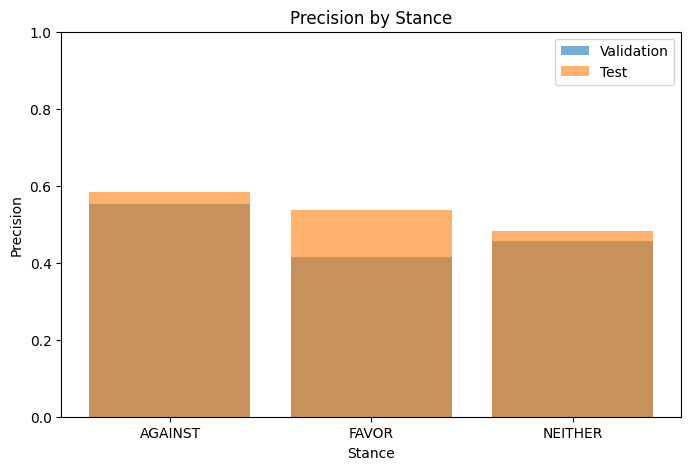

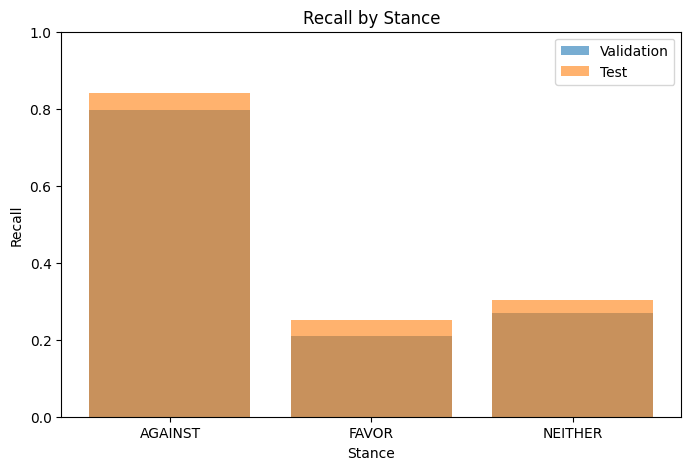

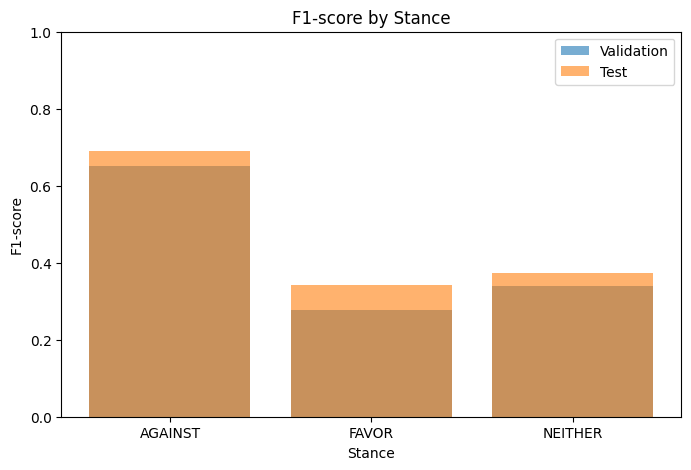

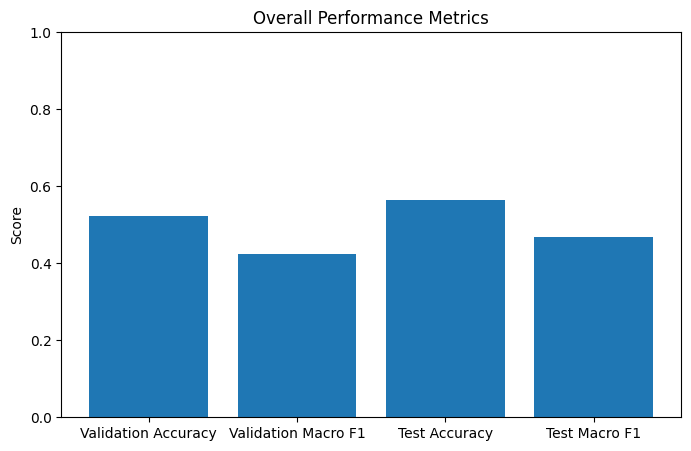

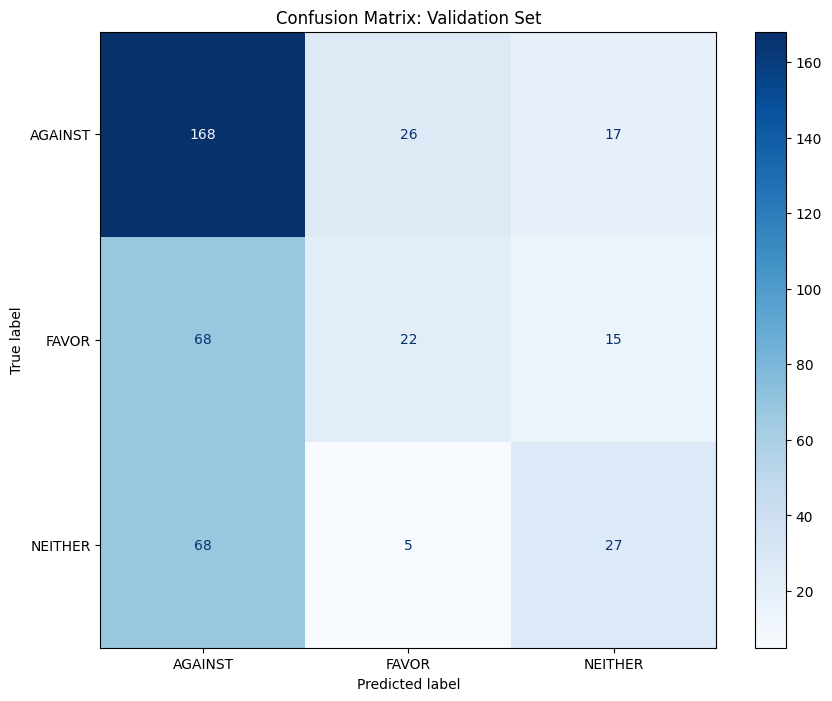

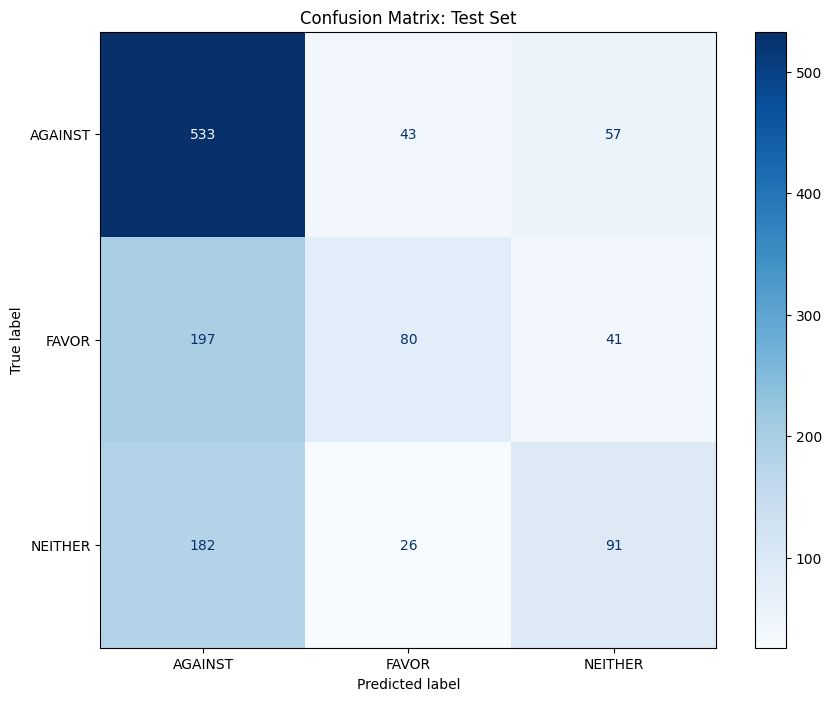

In [32]:
# Import necessary libraries
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load stance labels
train_labels = train_df["Stance"].iloc[:len(train_embeddings)]
dev_labels = dev_df["Stance"].iloc[:len(dev_embeddings)]
test_labels = test_df["Stance"].iloc[:len(test_embeddings)]

# Normalize BERT embeddings for Naive Bayes
scaler = MinMaxScaler()
train_embeddings_normalized = scaler.fit_transform(train_embeddings)
dev_embeddings_normalized = scaler.transform(dev_embeddings)
test_embeddings_normalized = scaler.transform(test_embeddings)

# Ensure matching lengths
assert len(train_embeddings_normalized) == len(train_labels), "Mismatch in train data size!"
assert len(dev_embeddings_normalized) == len(dev_labels), "Mismatch in dev data size!"
assert len(test_embeddings_normalized) == len(test_labels), "Mismatch in test data size!"

# Train Naive Bayes
nb_classifier = MultinomialNB()
nb_classifier.fit(train_embeddings_normalized, train_labels)

# Predict on validation and test sets
dev_predictions = nb_classifier.predict(dev_embeddings_normalized)
test_predictions = nb_classifier.predict(test_embeddings_normalized)

# ===== Step 4: Evaluate and Visualize ===== #

# Dynamically extract unique labels
unique_labels = np.unique(np.concatenate([train_labels, dev_labels, test_labels]))
print(f"Filtered Unique Labels: {unique_labels}")

# Validation set classification report
dev_report = classification_report(
    dev_labels,
    dev_predictions,
    labels=unique_labels,
    target_names=unique_labels,
    output_dict=True,
)
dev_report_df = pd.DataFrame(dev_report).transpose()

print("\nValidation Set Classification Report:")
print(dev_report_df)

# Test set classification report
test_report = classification_report(
    test_labels,
    test_predictions,
    labels=unique_labels,
    target_names=unique_labels,
    output_dict=True,
)
test_report_df = pd.DataFrame(test_report).transpose()

print("\nTest Set Classification Report:")
print(test_report_df)

# Overall accuracy for dev and test sets
dev_accuracy = accuracy_score(dev_labels, dev_predictions)
test_accuracy = accuracy_score(test_labels, test_predictions)
print(f"Validation Set Accuracy: {dev_accuracy:.4f}")
print(f"Test Set Accuracy: {test_accuracy:.4f}")

# Plot Precision, Recall, F1-Score by Stance
metrics = ["precision", "recall", "f1-score"]
for metric in metrics:
    plt.figure(figsize=(8, 5))
    plt.bar(unique_labels, dev_report_df.loc[unique_labels, metric], alpha=0.6, label="Validation")
    plt.bar(unique_labels, test_report_df.loc[unique_labels, metric], alpha=0.6, label="Test")
    plt.title(f"{metric.capitalize()} by Stance")
    plt.ylabel(metric.capitalize())
    plt.xlabel("Stance")
    plt.ylim(0, 1)
    plt.legend()
    plt.show()

# Macro F1 Score for validation and test sets
dev_macro_f1 = dev_report_df.loc["macro avg", "f1-score"]
test_macro_f1 = test_report_df.loc["macro avg", "f1-score"]

# Overall visualization
plt.figure(figsize=(8, 5))
plt.bar(
    ["Validation Accuracy", "Validation Macro F1", "Test Accuracy", "Test Macro F1"],
    [dev_accuracy, dev_macro_f1, test_accuracy, test_macro_f1],
)
plt.title("Overall Performance Metrics")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.show()

# Compute confusion matrices
dev_cm = confusion_matrix(dev_labels, dev_predictions, labels=unique_labels)
test_cm = confusion_matrix(test_labels, test_predictions, labels=unique_labels)

# Plot confusion matrices
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=dev_cm, display_labels=unique_labels)
disp.plot(cmap=plt.cm.Blues, ax=plt.gca(), colorbar=True)
plt.title("Confusion Matrix: Validation Set")
plt.show()

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=test_cm, display_labels=unique_labels)
disp.plot(cmap=plt.cm.Blues, ax=plt.gca(), colorbar=True)
plt.title("Confusion Matrix: Test Set")
plt.show()


# Model 2 Training Category-Specific Naive Bayes Models Using BERT Embeddings

Instead of combining all categories into a single model, individual models are trained for each category to capture category-specific contextual nuances. The process includes generating BERT embeddings, normalizing them, training separate classifiers, and evaluating the models with various performance metrics and visualizations.

The dataset is divided into subsets, each corresponding to a specific category (e.g., "Atheism", "Climate Change is a Real Concern"). This ensures that the stance detection is contextually relevant to the target category.

For each category, a Multinomial Naive Bayes classifier is trained using the normalized embeddings from the training subset. The trained classifier and the scaler are stored in a dictionary for future use.

By training separate models for each category, the system captures category-specific contextual cues, which are often overlooked in a generalized approach. This approach allows for more accurate stance detection within categories, as the model is specialized for each category's unique language patterns and stance distributions.

# Example Process for a Single Category
For the category "Atheism"

1. Extract the tweets and stance labels specific to "Atheism".

2. Generate BERT embeddings for these tweets.


3. Normalize the embeddings using MinMaxScaler.


4. Train a Naive Bayes classifier on the normalized embeddings and stance labels.

5. Evaluate the model's performance on the testing subset, displaying metrics such as:

* Precision: 0.93 for AGAINST, indicating high accuracy in predicting this stance.

* Recall: 0.71 for AGAINST, showing that the model correctly identifies 71% of tweets with this stance.

* F1-Score: 0.81 for AGAINST, providing a balanced measure of precision and recall.

6. Visualize the confusion matrix to identify patterns in predictions, such as confusion between NONE and AGAINST.


Training model for category: Feminist Movement

Validation Set Evaluation for category: Feminist Movement
              precision    recall  f1-score    support
AGAINST        0.540984  0.733333  0.622642  45.000000
FAVOR          0.166667  0.033333  0.055556  30.000000
NEITHER        0.315789  0.545455  0.400000  11.000000
accuracy       0.465116  0.465116  0.465116   0.465116
macro avg      0.341147  0.437374  0.359399  86.000000
weighted avg   0.381604  0.465116  0.396343  86.000000

Test Set Evaluation for category: Feminist Movement
              precision    recall  f1-score     support
AGAINST        0.664835  0.765823  0.711765  158.000000
FAVOR          0.366667  0.144737  0.207547   76.000000
NEITHER        0.413333  0.584906  0.484375   53.000000
accuracy       0.567944  0.567944  0.567944    0.567944
macro avg      0.481612  0.498488  0.467896  287.000000
weighted avg   0.539433  0.567944  0.536252  287.000000

Confusion Matrix: Validation Set


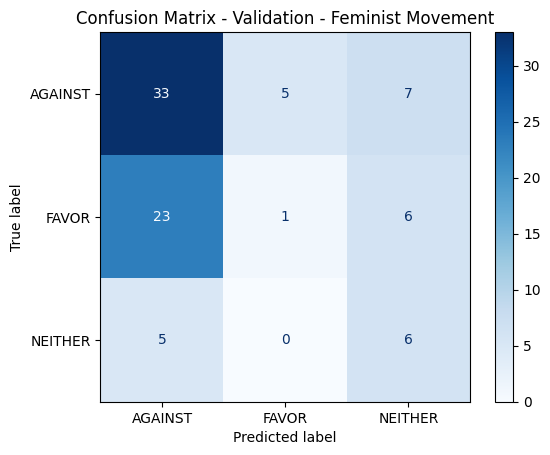


Confusion Matrix: Test Set


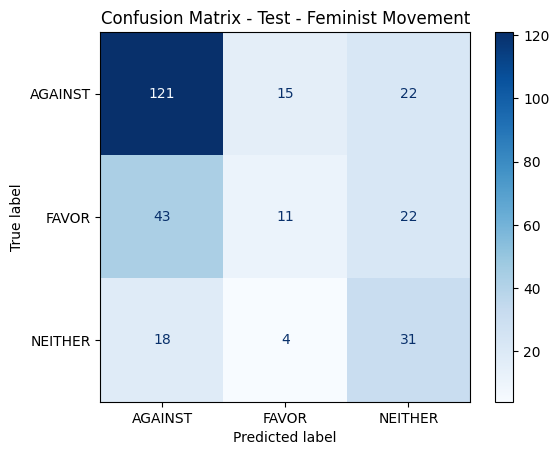


Training model for category: Hillary Clinton

Validation Set Evaluation for category: Hillary Clinton
              precision    recall  f1-score     support
AGAINST        0.764706  0.825397  0.793893   63.000000
FAVOR          0.500000  0.461538  0.480000   13.000000
NEITHER        0.708333  0.607143  0.653846   28.000000
accuracy       0.721154  0.721154  0.721154    0.721154
macro avg      0.657680  0.631359  0.642580  104.000000
weighted avg   0.716440  0.721154  0.716952  104.000000

Test Set Evaluation for category: Hillary Clinton
              precision    recall  f1-score     support
AGAINST        0.659574  0.760736  0.706553  163.000000
FAVOR          0.473684  0.352941  0.404494   51.000000
NEITHER        0.568966  0.471429  0.515625   70.000000
accuracy       0.616197  0.616197  0.616197    0.616197
macro avg      0.567408  0.528369  0.542224  284.000000
weighted avg   0.603860  0.616197  0.605250  284.000000

Confusion Matrix: Validation Set


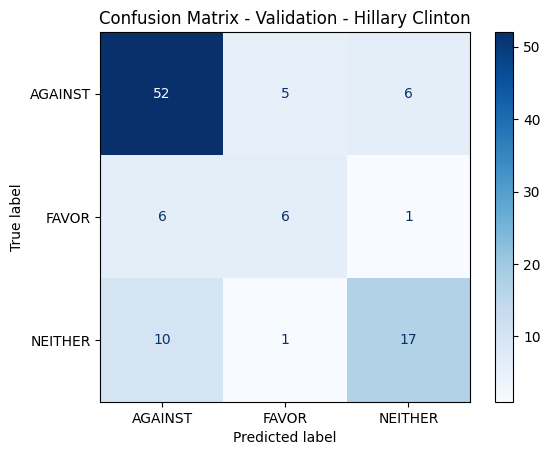


Confusion Matrix: Test Set


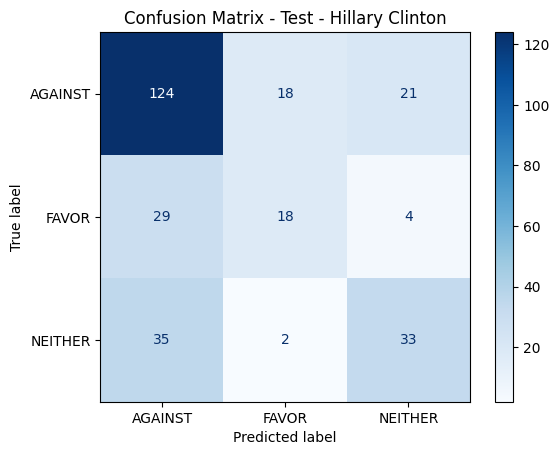


Training model for category: Legalization of Abortion

Validation Set Evaluation for category: Legalization of Abortion
              precision    recall  f1-score    support
AGAINST        0.655738  0.677966  0.666667  59.000000
FAVOR          0.214286  0.214286  0.214286  14.000000
NEITHER        0.565217  0.520000  0.541667  25.000000
accuracy       0.571429  0.571429  0.571429   0.571429
macro avg      0.478414  0.470751  0.474206  98.000000
weighted avg   0.569581  0.571429  0.570153  98.000000

Test Set Evaluation for category: Legalization of Abortion
              precision    recall  f1-score     support
AGAINST        0.663102  0.770186  0.712644  161.000000
FAVOR          0.418605  0.339623  0.375000   53.000000
NEITHER        0.538462  0.411765  0.466667   68.000000
accuracy       0.602837  0.602837  0.602837    0.602837
macro avg      0.540056  0.507191  0.518103  282.000000
weighted avg   0.587095  0.602837  0.589872  282.000000

Confusion Matrix: Validation Set


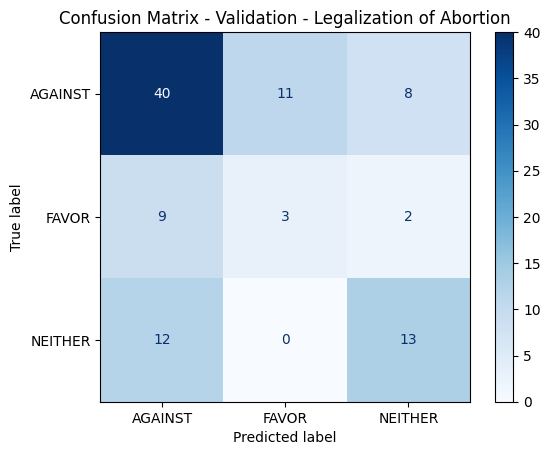


Confusion Matrix: Test Set


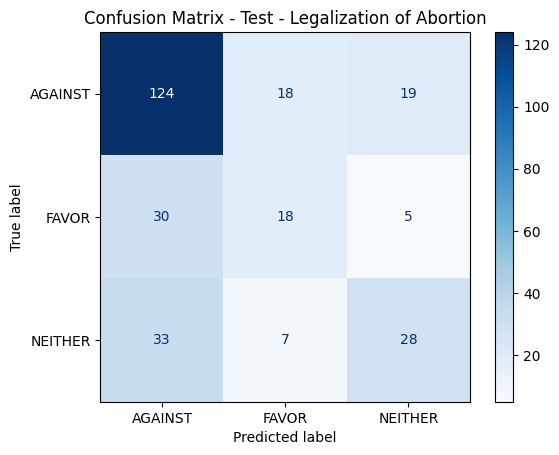


Training model for category: Atheism

Validation Set Evaluation for category: Atheism
              precision    recall  f1-score    support
AGAINST        0.904762  0.883721  0.894118  43.000000
FAVOR          0.444444  0.500000  0.470588   8.000000
NEITHER        0.642857  0.642857  0.642857  14.000000
accuracy       0.784615  0.784615  0.784615   0.784615
macro avg      0.664021  0.675526  0.669188  65.000000
weighted avg   0.791697  0.784615  0.787873  65.000000

Test Set Evaluation for category: Atheism
              precision    recall  f1-score     support
AGAINST        0.912698  0.798611  0.851852  144.000000
FAVOR          0.446809  0.600000  0.512195   35.000000
NEITHER        0.640000  0.727273  0.680851   44.000000
accuracy       0.753363  0.753363  0.753363    0.753363
macro avg      0.666502  0.708628  0.681633  223.000000
weighted avg   0.785771  0.753363  0.764802  223.000000

Confusion Matrix: Validation Set


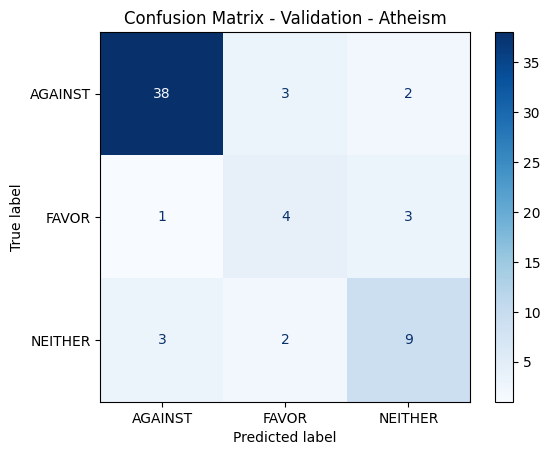


Confusion Matrix: Test Set


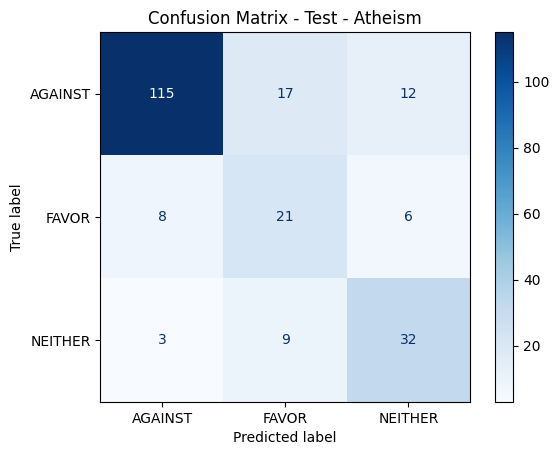


Training model for category: Climate Change is a Real Concern

Validation Set Evaluation for category: Climate Change is a Real Concern
              precision    recall  f1-score    support
AGAINST        0.000000  0.000000  0.000000   1.000000
FAVOR          0.866667  0.650000  0.742857  40.000000
NEITHER        0.575758  0.863636  0.690909  22.000000
accuracy       0.714286  0.714286  0.714286   0.714286
macro avg      0.480808  0.504545  0.477922  63.000000
weighted avg   0.751323  0.714286  0.712925  63.000000

Test Set Evaluation for category: Climate Change is a Real Concern
              precision    recall  f1-score     support
AGAINST        0.000000  0.000000  0.000000    7.000000
FAVOR          0.781250  0.728155  0.753769  103.000000
NEITHER        0.615385  0.750000  0.676056   64.000000
accuracy       0.706897  0.706897  0.706897    0.706897
macro avg      0.465545  0.492718  0.476608  174.000000
weighted avg   0.688812  0.706897  0.694861  174.000000

Confusion Matrix:

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

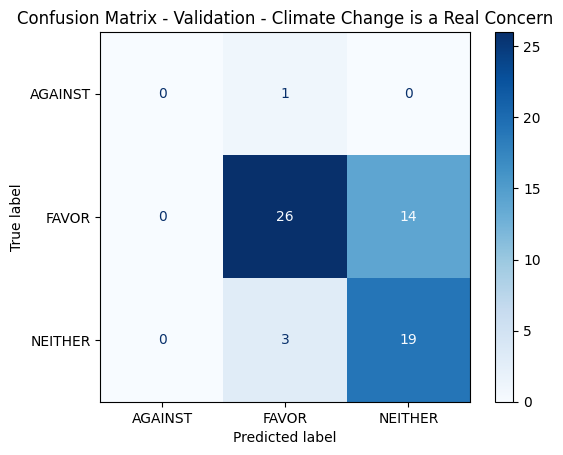


Confusion Matrix: Test Set


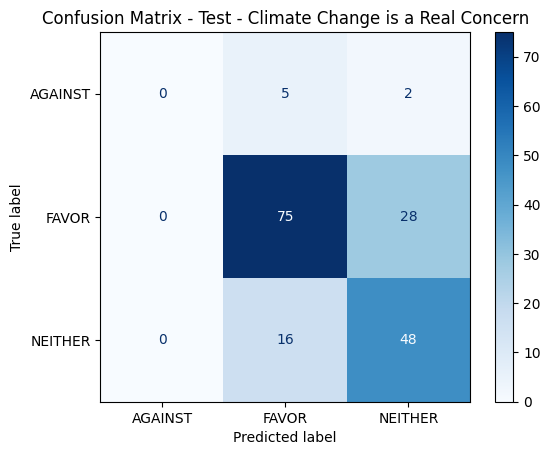

In [33]:
# ===== Train Separate Models for Each Category ===== #
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score
from transformers import BertTokenizer, BertModel
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Categories in the dataset
categories = train_df["Target"].unique()

# Initialize category models
category_models = {}

# Load BERT model and tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Function to generate BERT embeddings
def get_bert_embeddings(texts):
    embeddings = []
    model.eval()
    with torch.no_grad():
        for text in texts:
            inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=128)
            inputs = {key: val.to(device) for key, val in inputs.items()}
            outputs = model(**inputs)
            cls_embedding = outputs.last_hidden_state[:, 0, :]
            embeddings.append(cls_embedding.cpu().numpy())
    return np.vstack(embeddings)

# Train and evaluate models for each category
for category in categories:
    print(f"\nTraining model for category: {category}")

    # Filter data for the current category
    train_subset = train_df[train_df["Target"] == category]
    dev_subset = dev_df[dev_df["Target"] == category]
    test_subset = test_df[test_df["Target"] == category]

    # Generate BERT embeddings
    train_embeddings = get_bert_embeddings(train_subset["Preprocessed Tweet"].tolist())
    dev_embeddings = get_bert_embeddings(dev_subset["Preprocessed Tweet"].tolist())
    test_embeddings = get_bert_embeddings(test_subset["Preprocessed Tweet"].tolist())

    # Normalize embeddings
    scaler = MinMaxScaler()
    train_embeddings_normalized = scaler.fit_transform(train_embeddings)
    dev_embeddings_normalized = scaler.transform(dev_embeddings)
    test_embeddings_normalized = scaler.transform(test_embeddings)

    # Train Naive Bayes
    nb_classifier = MultinomialNB()
    nb_classifier.fit(train_embeddings_normalized, train_subset["Stance"])

    # Save the model and scaler for the category
    category_models[category] = {
        "model": nb_classifier,
        "scaler": scaler
    }

    # Predict on validation and test sets
    dev_predictions = nb_classifier.predict(dev_embeddings_normalized)
    test_predictions = nb_classifier.predict(test_embeddings_normalized)

    # Evaluate on validation set
    print(f"\nValidation Set Evaluation for category: {category}")
    dev_report = classification_report(dev_subset["Stance"], dev_predictions, output_dict=True)
    print(pd.DataFrame(dev_report).transpose())

    # Evaluate on test set
    print(f"\nTest Set Evaluation for category: {category}")
    test_report = classification_report(test_subset["Stance"], test_predictions, output_dict=True)
    print(pd.DataFrame(test_report).transpose())

    # Confusion matrices
    print("\nConfusion Matrix: Validation Set")
    ConfusionMatrixDisplay.from_predictions(dev_subset["Stance"], dev_predictions, cmap="Blues")
    plt.title(f"Confusion Matrix - Validation - {category}")
    plt.show()

    print("\nConfusion Matrix: Test Set")
    ConfusionMatrixDisplay.from_predictions(test_subset["Stance"], test_predictions, cmap="Blues")
    plt.title(f"Confusion Matrix - Test - {category}")
    plt.show()


Model Training and Evaluation for Each Category

# Model 3 Two-Stage Hybrid Model for Target and Stance Classification

This implementation introduces a two-stage hybrid model combining Logistic Regression with TF-IDF features for target classification and Naive Bayes with BERT embeddings for stance detection. The model focuses on separating the task of target classification from stance classification to improve performance and analyze error propagation between stages.

For target classification, TF-IDF vectorization transforms the tweets into numerical features, capturing both unigrams and bigrams, followed by Logistic Regression with hyperparameter tuning using Grid Search for optimal performance. This stage is evaluated with metrics such as precision, recall, and F1-score, along with a confusion matrix for visualizing inter-category misclassifications.

In the second stage, stance detection is performed separately for each target category. BERT embeddings are extracted to encode the semantic meaning of each tweet, normalized using MinMaxScaler, and used to train category-specific Multinomial Naive Bayes classifiers to predict stances (AGAINST, FAVOR, or NONE).  The hybrid approach evaluates performance on correctly predicted target categories to isolate the stance model’s effectiveness while also analyzing the cascading effect of target misclassifications by predicting stances based on incorrect categories. Both scenarios are evaluated using classification metrics and confusion matrices, offering a comprehensive understanding of error propagation.

Topic Classification Report:
                                  precision    recall  f1-score   support

                         Atheism       0.71      0.70      0.70        89
Climate Change is a Real Concern       0.66      0.70      0.68        66
               Feminist Movement       0.70      0.76      0.73       115
                 Hillary Clinton       0.80      0.76      0.78       119
        Legalization of Abortion       0.69      0.65      0.67       111

                        accuracy                           0.72       500
                       macro avg       0.71      0.71      0.71       500
                    weighted avg       0.72      0.72      0.72       500



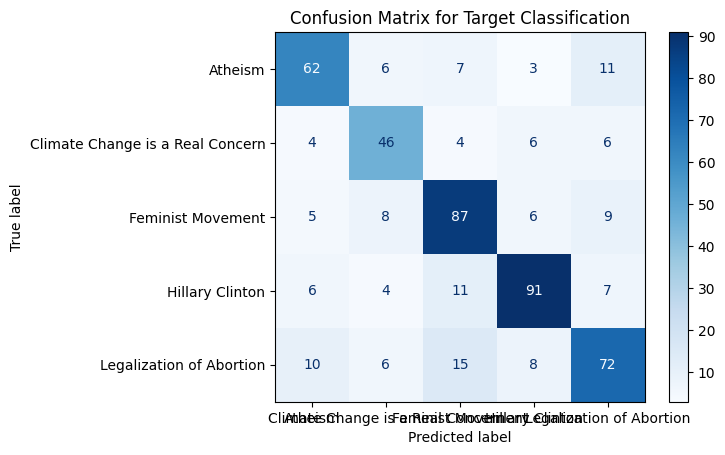

Training Stance Model for Category: Feminist Movement
Stance Classification Report for Feminist Movement:
              precision    recall  f1-score   support

     AGAINST       0.66      0.77      0.71       158
       FAVOR       0.37      0.14      0.21        76
     NEITHER       0.41      0.58      0.48        53

    accuracy                           0.57       287
   macro avg       0.48      0.50      0.47       287
weighted avg       0.54      0.57      0.54       287



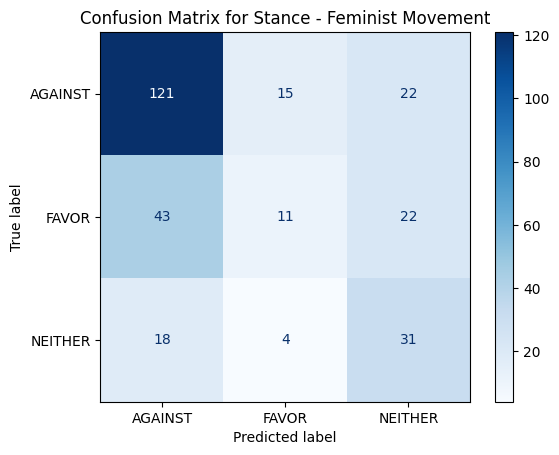

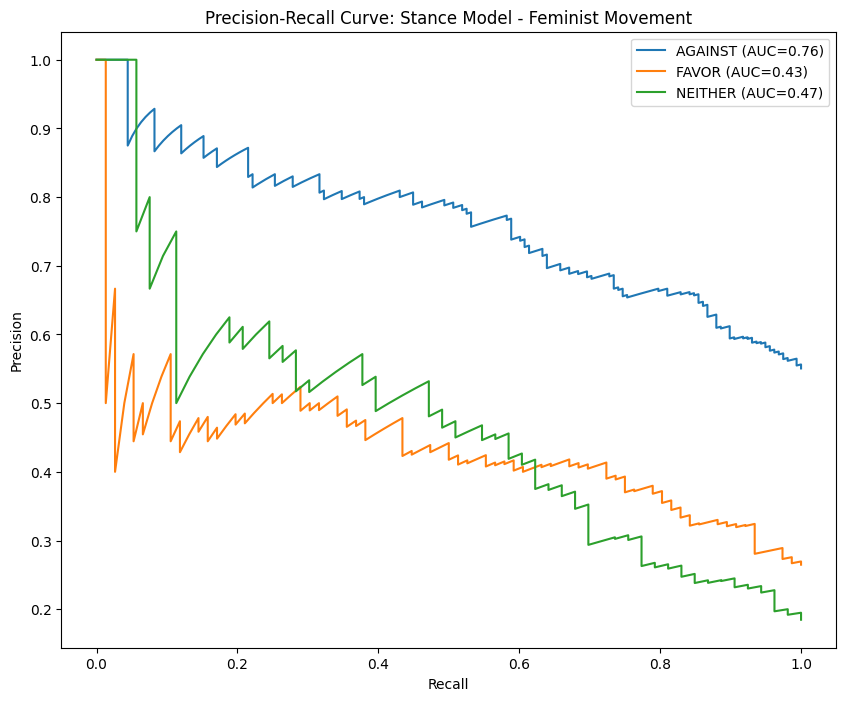

Training Stance Model for Category: Hillary Clinton
Stance Classification Report for Hillary Clinton:
              precision    recall  f1-score   support

     AGAINST       0.66      0.76      0.71       163
       FAVOR       0.47      0.35      0.40        51
     NEITHER       0.57      0.47      0.52        70

    accuracy                           0.62       284
   macro avg       0.57      0.53      0.54       284
weighted avg       0.60      0.62      0.61       284



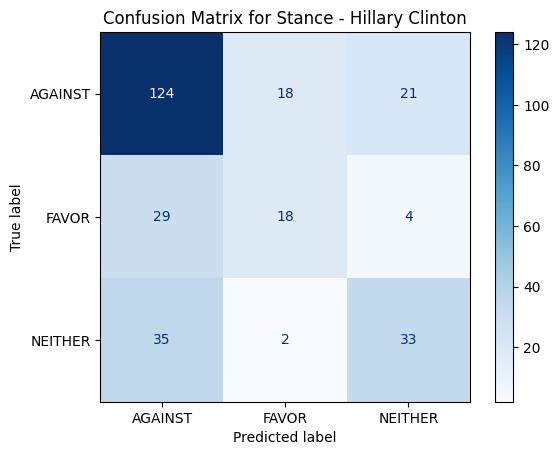

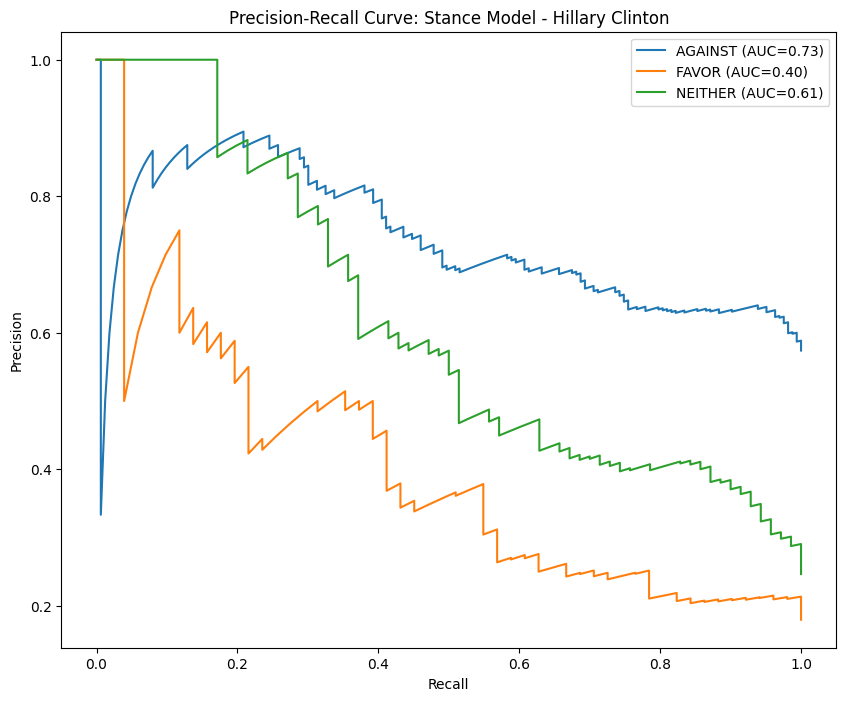

Training Stance Model for Category: Legalization of Abortion
Stance Classification Report for Legalization of Abortion:
              precision    recall  f1-score   support

     AGAINST       0.66      0.77      0.71       161
       FAVOR       0.42      0.34      0.38        53
     NEITHER       0.54      0.41      0.47        68

    accuracy                           0.60       282
   macro avg       0.54      0.51      0.52       282
weighted avg       0.59      0.60      0.59       282



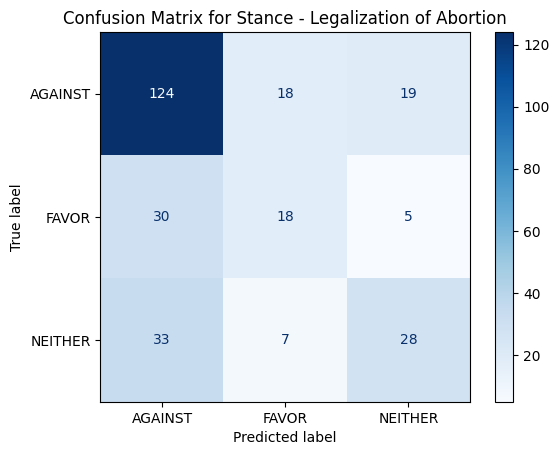

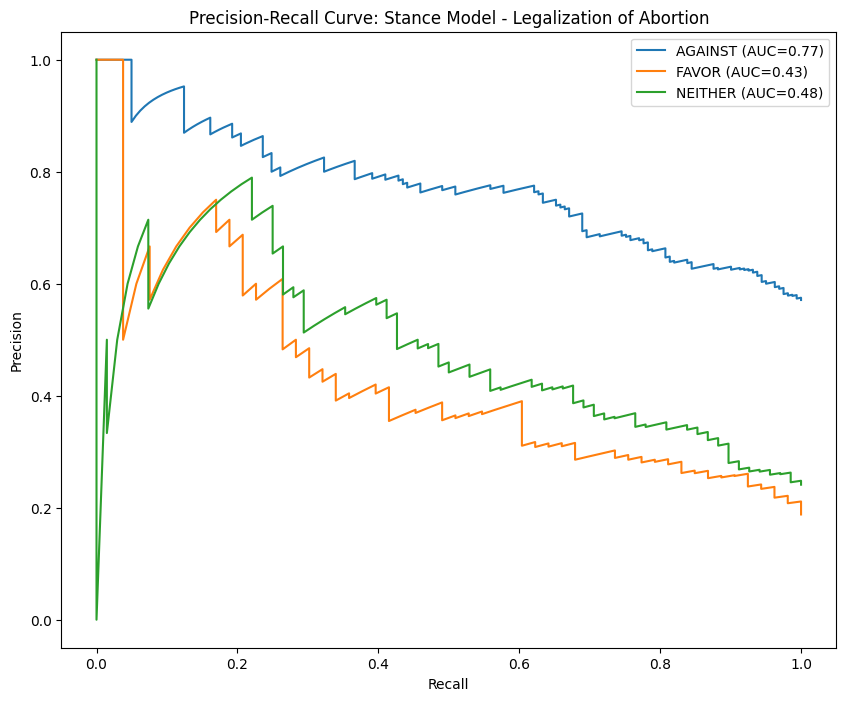

Training Stance Model for Category: Atheism
Stance Classification Report for Atheism:
              precision    recall  f1-score   support

     AGAINST       0.91      0.80      0.85       144
       FAVOR       0.45      0.60      0.51        35
     NEITHER       0.64      0.73      0.68        44

    accuracy                           0.75       223
   macro avg       0.67      0.71      0.68       223
weighted avg       0.79      0.75      0.76       223



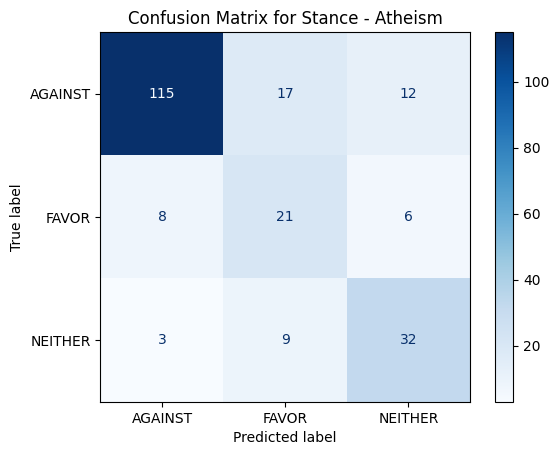

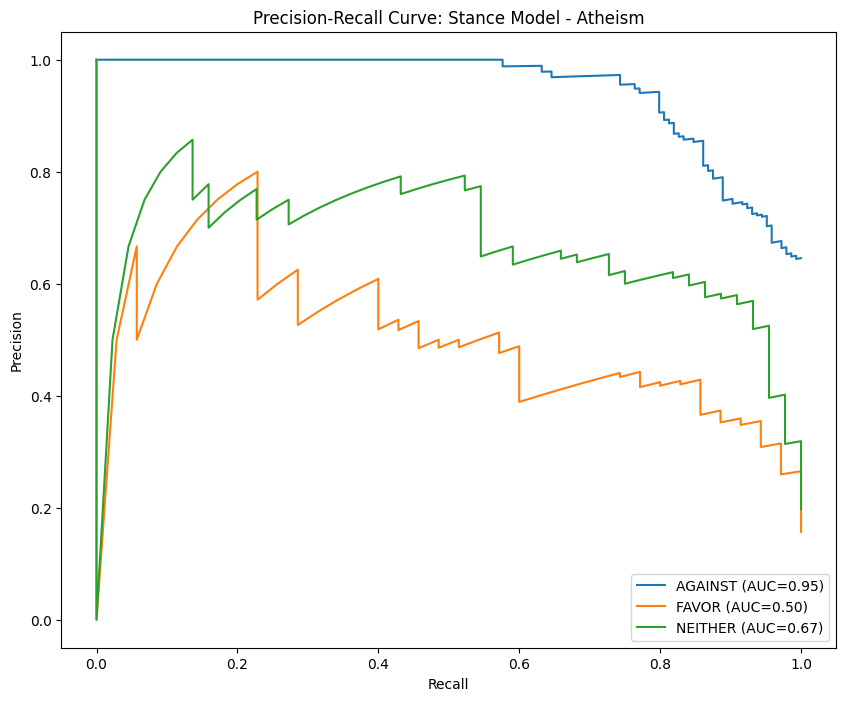

Training Stance Model for Category: Climate Change is a Real Concern
Stance Classification Report for Climate Change is a Real Concern:
              precision    recall  f1-score   support

     AGAINST       0.00      0.00      0.00         7
       FAVOR       0.78      0.73      0.75       103
     NEITHER       0.62      0.75      0.68        64

    accuracy                           0.71       174
   macro avg       0.47      0.49      0.48       174
weighted avg       0.69      0.71      0.69       174



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


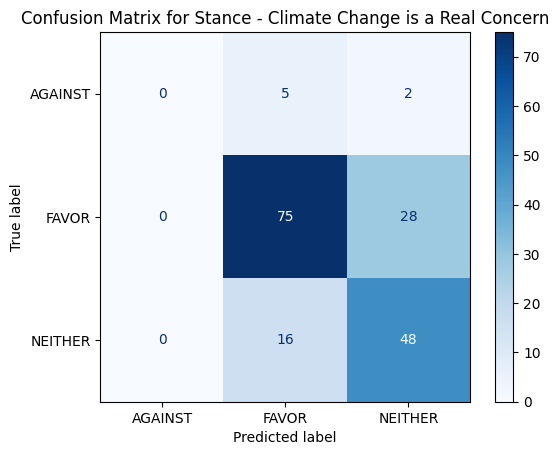

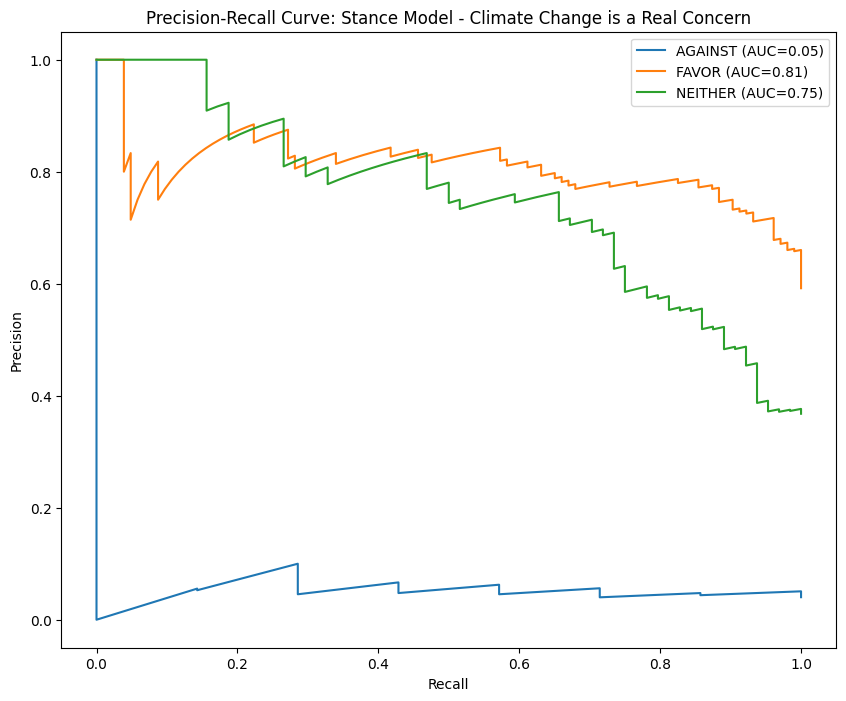

In [35]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, precision_recall_curve, auc
from transformers import BertTokenizer, BertModel
import torch
import numpy as np
import matplotlib.pyplot as plt

# ===== Preprocessing Text ===== #
def preprocess_text(df, text_column):
    df["Preprocessed Tweet"] = df[text_column].apply(lambda x: x.lower())
    df["Preprocessed Tweet"] = df["Preprocessed Tweet"].apply(
        lambda x: re.sub(r"[^\w\s/#-]+", " ", x)
    )
    df["Preprocessed Tweet"] = df["Preprocessed Tweet"].apply(
        lambda x: re.sub(r"\s+", " ", x).strip()
    )
    return df

# ===== Train Target Classifier ===== #
def train_topic_classifier(train_df):
    X = train_df["Preprocessed Tweet"]
    y = train_df["Target"]

    vectorizer = TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        stop_words="english",
        min_df=3,
        max_df=0.8,
        sublinear_tf=True,
        norm="l2"
    )
    X_tfidf = vectorizer.fit_transform(X)

    X_train, X_val, y_train, y_val = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

    param_grid = {"C": [0.1, 1, 10], "solver": ["liblinear"]}
    grid_search = GridSearchCV(
        LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
        param_grid,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    y_pred = best_model.predict(X_val)
    print("Topic Classification Report:")
    print(classification_report(y_val, y_pred))

    ConfusionMatrixDisplay.from_predictions(y_val, y_pred, cmap="Blues")
    plt.title("Confusion Matrix for Target Classification")
    plt.show()

    return best_model, vectorizer

# Precision-Recall Curve Visualization
def plot_precision_recall_curves(y_true, y_probs, classes, model_name):
    plt.figure(figsize=(10, 8))
    for i, class_label in enumerate(classes):
        y_true_bin = (np.array(y_true) == class_label).astype(int)
        precision, recall, _ = precision_recall_curve(y_true_bin, y_probs[:, i])
        pr_auc = auc(recall, precision)
        plt.plot(recall, precision, label=f"{class_label} (AUC={pr_auc:.2f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve: {model_name}")
    plt.legend(loc="best")
    plt.show()

# ===== Extract BERT Embeddings ===== #
def get_bert_embeddings(texts, tokenizer, model, device):
    embeddings = []
    model.eval()
    with torch.no_grad():
        for text in texts:
            inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
            inputs = {key: val.to(device) for key, val in inputs.items()}
            outputs = model(**inputs)
            cls_embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(cls_embedding)
    return np.vstack(embeddings)

# ===== Train Stance Model ===== #
def train_stance_model(train_df, test_df, category, tokenizer, model, device):
    train_subset = train_df[train_df["Target"] == category]
    test_subset = test_df[test_df["Target"] == category]

    train_embeddings = get_bert_embeddings(train_subset["Preprocessed Tweet"].tolist(), tokenizer, model, device)
    test_embeddings = get_bert_embeddings(test_subset["Preprocessed Tweet"].tolist(), tokenizer, model, device)

    scaler = MinMaxScaler()
    train_embeddings_normalized = scaler.fit_transform(train_embeddings)
    test_embeddings_normalized = scaler.transform(test_embeddings)

    nb_classifier = MultinomialNB()
    nb_classifier.fit(train_embeddings_normalized, train_subset["Stance"])

    test_predictions = nb_classifier.predict(test_embeddings_normalized)
    test_probs = nb_classifier.predict_proba(test_embeddings_normalized)

    print(f"Stance Classification Report for {category}:")
    print(classification_report(test_subset["Stance"], test_predictions))

    ConfusionMatrixDisplay.from_predictions(test_subset["Stance"], test_predictions, cmap="Blues")
    plt.title(f"Confusion Matrix for Stance - {category}")
    plt.show()

    classes = nb_classifier.classes_
    plot_precision_recall_curves(test_subset["Stance"], test_probs, classes, f"Stance Model - {category}")

    return {"model": nb_classifier, "scaler": scaler}

# ===== Main Workflow ===== #
def main(data_file):
    df = pd.read_excel(data_file)

    # Filter out rows where Target is "Donald Trump"
    df = df[df["Target"] != "Donald Trump"]

    # Preprocess text
    df = preprocess_text(df, "Tweet")

    # Split dataset
    train_df, temp_df = train_test_split(df, test_size=0.40, random_state=42, stratify=df["Stance"])
    dev_df, test_df = train_test_split(temp_df, test_size=0.75, random_state=42, stratify=temp_df["Stance"])

    topic_classifier, vectorizer = train_topic_classifier(train_df)

    tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
    model = BertModel.from_pretrained("bert-base-uncased")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    category_models = {}
    for category in train_df["Target"].unique():
        print(f"Training Stance Model for Category: {category}")
        category_models[category] = train_stance_model(train_df, test_df, category, tokenizer, model, device)

# ===== Execute ===== #
data_file = "Tweets.xlsx"
main(data_file)


# Naive Bayes Baseline Model

The purpose of this code block is to use the Naive Bayes model as a baseline model in the stance detection task and compare its results with a more complex hybrid model (BERT + Naive Bayes). In this process, the metrics of both models are evaluated and their performances are visualized with precision-recall curves.

Training set size: 2497
Development set size: 416
Test set size: 1250

Naive Bayes (Baseline) Classification Report:
              precision    recall  f1-score   support

     AGAINST       0.58      0.93      0.71       633
       FAVOR       0.65      0.31      0.41       318
     NEITHER       0.66      0.20      0.31       299

    accuracy                           0.60      1250
   macro avg       0.63      0.48      0.48      1250
weighted avg       0.62      0.60      0.54      1250



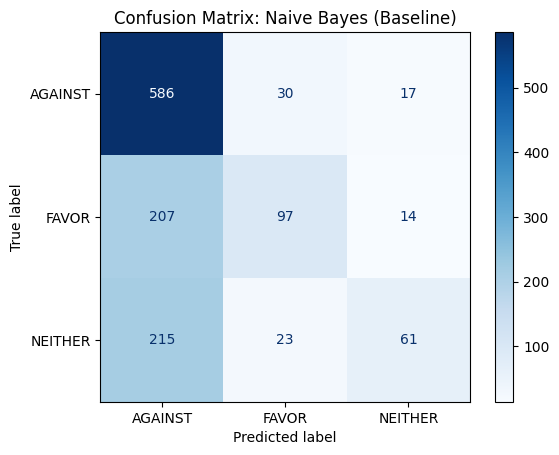

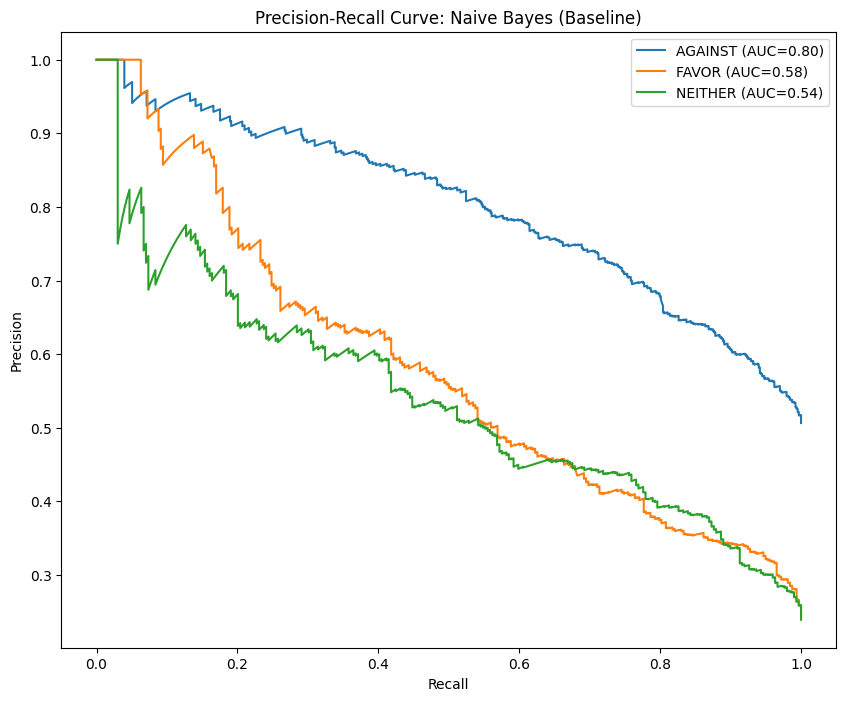

In [36]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# ===== Preprocessing Text ===== #
def preprocess_text(df, text_column):
    df["Preprocessed Tweet"] = df[text_column].apply(lambda x: x.lower())
    df["Preprocessed Tweet"] = df["Preprocessed Tweet"].apply(
        lambda x: re.sub(r"[^\w\s/#-]+", " ", x)
    )
    df["Preprocessed Tweet"] = df["Preprocessed Tweet"].apply(
        lambda x: re.sub(r"\s+", " ", x)
    )
    return df


def plot_precision_recall_curves(y_true, y_probs, classes):
    plt.figure(figsize=(10, 8))
    for i, class_label in enumerate(classes):

        y_true_bin = (np.array(y_true) == class_label).astype(int)
        precision, recall, _ = precision_recall_curve(y_true_bin, y_probs[:, i])
        pr_auc = auc(recall, precision)
        plt.plot(recall, precision, label=f"{class_label} (AUC={pr_auc:.2f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve: Naive Bayes (Baseline)")
    plt.legend(loc="best")
    plt.show()

# ===== Naive Bayes Baseline Model ===== #
def train_naive_bayes_baseline(train_df, test_df):

    vectorizer = TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        stop_words="english",
        min_df=3,
        max_df=0.8,
        sublinear_tf=True,
        norm="l2"
    )
    X_train = vectorizer.fit_transform(train_df["Preprocessed Tweet"])
    y_train = train_df["Stance"]

    X_test = vectorizer.transform(test_df["Preprocessed Tweet"])
    y_test = test_df["Stance"]


    nb_model = MultinomialNB()
    nb_model.fit(X_train, y_train)


    y_pred = nb_model.predict(X_test)
    y_probs = nb_model.predict_proba(X_test)

    # Classification Report
    print("\nNaive Bayes (Baseline) Classification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
    plt.title("Confusion Matrix: Naive Bayes (Baseline)")
    plt.show()

    # Precision-Recall Eğrisi
    plot_precision_recall_curves(y_test, y_probs, nb_model.classes_)

# ===== Main Workflow ===== #
def main(data_file):

    df = pd.read_excel(data_file)


    df = df[df['Target'] != 'Donald Trump']


    df = preprocess_text(df, "Tweet")


    train_df, temp_df = train_test_split(df, test_size=0.40, random_state=42, stratify=df["Stance"])
    dev_df, test_df = train_test_split(temp_df, test_size=0.75, random_state=42, stratify=temp_df["Stance"])

    print(f"Training set size: {len(train_df)}")
    print(f"Development set size: {len(dev_df)}")
    print(f"Test set size: {len(test_df)}")

    # Naive Bayes Baseline Model
    train_naive_bayes_baseline(train_df, test_df)

# ===== Execute ===== #
data_file = "Tweets.xlsx"
main(data_file)
